# EDA
El objetivo es conseguir responder a estas preguntas: 

1. ¿A qué edad alcanzan el pico de rendimiento los atletas (medido con Dots) y difiere entre hombres y mujeres?
2. ¿Cómo progresan los atletas dentro de una competición? ¿Suben de peso entre intentos 1 → 2 → 3 o tienden a repetir/bajar?
3. ¿En qué levantamiento (squat, bench, deadlift) se producen más fallos en el 3er intento?
4. ¿Los atletas que compiten en más eventos full lifting rinden más o menos que los que se especializan en un sólo tipo de levantamiento?
5. ¿El 4º intento permite a los atletas superar su mejor marca de los 3 primeros? ¿Cuál es la tasa de éxito?

Para ello, haremos un filtrado antes si quiera de explorar los datos, ya que gracias a OPL_guide tengo contexto de todas las columnas. Después, exploraré, limpiaré y finalmente analizaré el dataset.

## 1. Importar librerías

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import pingouin as pg

## 2. Set Up

### Condiciones del display
El objetivo es que todos los display se vean iguales y obligarlo a mostrar todas las columnas para poder visualizar mejor los datos.

In [2]:
# Mostrar todas las columnas (sin cortar)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Mostrar decimales con 2 cifras nada más.
pd.set_option('display.float_format', '{:.2f}'.format)

### Cargar el dataset
Además de cargar el archivo, voy a eliminar directamente algunas columnas que sé que no voy a utilizar para reducir el volumen de datos, que con un dataset tan grande, es importante. Además, cómo la idea es que los resultados sean lo más útiles y aplicables posible, voy a filtrar el dataset por `Sanctioned` y `Tested`, con la idea de asegurarme que era una competición oficial y que además, _a priori_, los atletas no consumen sustancias dopantes. También eliminaré aquellas filas donde los participantes no se presentarion `Place = NS` o fallaron un test de dopaje `Place = DD`.

Las columnas eliminadas de primeras son:

- `Country`, `State`, `MeetState`, `MeetTown`, `MeetCountry`, `ParentFederation`, `MeetName`, `Division`: Información excesiva sobre la competición o participante (especialmente nombres y localización) que no voy a utilizar.
- `Sanctioned` y `Tested`: Una vez filtrado el df por estas columnas, no las necesito para nada más.

In [3]:
opl_df = pd.read_csv('../data/OPL_dataset.csv', low_memory = False)

filtered_df = opl_df[(opl_df['Sanctioned'] == 'Yes') & (opl_df['Tested'] == 'Yes') & (opl_df['Place'] != 'DD') & (opl_df['Place'] != 'NS')]

filtered_df = filtered_df.drop(columns = ['Country', 'State', 'MeetState', 'MeetTown', 'MeetCountry', 'ParentFederation', 'MeetName', 'Division', 'Sanctioned', 'Tested'])

## 3. Explorar el dataset

### 3.1. Exploración general

In [4]:
display(filtered_df.head())

,Name,Sex,Event,Equipment,Age,AgeClass,BirthYearClass,BodyweightKg,WeightClassKg,Squat1Kg,Squat2Kg,Squat3Kg,Squat4Kg,Best3SquatKg,Bench1Kg,Bench2Kg,Bench3Kg,Bench4Kg,Best3BenchKg,Deadlift1Kg,Deadlift2Kg,Deadlift3Kg,Deadlift4Kg,Best3DeadliftKg,TotalKg,Place,Dots,Wilks,Glossbrenner,Goodlift,Federation,Date
726,Maysar Olaymi,M,B,Raw,24.00,24-34,24-39,43.50,49,NaN,NaN,NaN,NaN,NaN,-85.00,85.00,91.00,NaN,91.00,NaN,NaN,NaN,NaN,NaN,91.00,1,104.83,109.30,108.45,65.25,WPPO,2017-02-21
727,Mohammad Alshnaiti,M,B,Raw,15.00,13-15,14-18,39.50,49,NaN,NaN,NaN,NaN,NaN,70.00,-80.00,-80.00,NaN,70.00,NaN,NaN,NaN,NaN,NaN,70.00,2,88.98,93.48,92.70,53.03,WPPO,2017-02-21
728,Ali Alzeyoudi,M,B,Raw,14.00,13-15,14-18,47.50,49,NaN,NaN,NaN,NaN,NaN,-26.00,-26.00,-26.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DQ,NaN,NaN,NaN,NaN,WPPO,2017-02-21
729,Osama Albalushi,M,B,Raw,14.00,13-15,14-18,53.95,54,NaN,NaN,NaN,NaN,NaN,-64.00,-64.00,-64.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DQ,NaN,NaN,NaN,NaN,WPPO,2017-02-21
730,Ali Al-Darraji,M,B,Raw,35.00,35-39,24-39,52.30,54,NaN,NaN,NaN,NaN,NaN,135.00,140.00,142.00,NaN,142.00,NaN,NaN,NaN,NaN,NaN,142.00,1,135.27,138.51,136.36,91.68,WPPO,2017-02-21


### 3.2. Filas, columnas y tipos

In [5]:
filtered_df.info()
print("---------------------------------------")
print(f"Número de filas: {filtered_df.shape[0]}")
print(f"Número de columnas: {filtered_df.shape[1]}")

<class 'pandas.DataFrame'>
Index: 2961526 entries, 726 to 3920661
Data columns (total 32 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Name             str    
 1   Sex              str    
 2   Event            str    
 3   Equipment        str    
 4   Age              float64
 5   AgeClass         str    
 6   BirthYearClass   str    
 7   BodyweightKg     float64
 8   WeightClassKg    str    
 9   Squat1Kg         float64
 10  Squat2Kg         float64
 11  Squat3Kg         float64
 12  Squat4Kg         float64
 13  Best3SquatKg     float64
 14  Bench1Kg         float64
 15  Bench2Kg         float64
 16  Bench3Kg         float64
 17  Bench4Kg         float64
 18  Best3BenchKg     float64
 19  Deadlift1Kg      float64
 20  Deadlift2Kg      float64
 21  Deadlift3Kg      float64
 22  Deadlift4Kg      float64
 23  Best3DeadliftKg  float64
 24  TotalKg          float64
 25  Place            str    
 26  Dots             float64
 27  Wilks            float64
 

### 3.3. Estadística de las variables

In [6]:
print("----------------- ANÁLISIS VARIABLES NUMÉRICAS -----------------")
display(filtered_df.describe())


print("----------------- ANÁLISIS VARIABLES CATEGÓRICAS -----------------")
print(" 1. Sexo")
display(filtered_df['Sex'].value_counts())

print(" 2. Levantamientos realizados")
display(filtered_df['Event'].value_counts())

print(" 3. Equipamiento permitido")
display(filtered_df['Equipment'].value_counts())

print(" 4. Podium")
display(filtered_df['Place'].value_counts())

print(" 5. Federación")
display(filtered_df['Federation'].value_counts())

----------------- ANÁLISIS VARIABLES NUMÉRICAS -----------------


,Age,BodyweightKg,Squat1Kg,Squat2Kg,Squat3Kg,Squat4Kg,Best3SquatKg,Bench1Kg,Bench2Kg,Bench3Kg,Bench4Kg,Best3BenchKg,Deadlift1Kg,Deadlift2Kg,Deadlift3Kg,Deadlift4Kg,Best3DeadliftKg,TotalKg,Dots,Wilks,Glossbrenner,Goodlift
count,1766516.00,2948887.00,965026.00,956111.00,935976.00,4511.00,2203019.00,1347230.00,1334051.00,1301308.00,11913.00,2688751.00,1034884.00,1019672.00,988989.00,13853.00,2292845.00,2768811.00,2756977.00,2756977.00,2756977.00,2586604.00
mean,29.87,82.10,116.62,104.09,46.69,94.16,164.93,81.05,58.26,-10.21,50.43,108.62,158.22,136.51,28.61,112.57,179.57,377.70,283.69,282.63,265.11,62.54
std,13.45,22.51,125.13,147.65,180.88,150.31,63.11,88.04,111.70,129.43,137.36,49.04,100.58,145.57,205.43,152.45,59.65,191.10,120.11,119.64,113.73,15.89
min,0.00,15.10,-477.50,-500.00,-525.00,-462.50,-440.00,-635.50,-635.50,-575.00,-440.00,-362.50,-500.00,-502.50,-587.50,-405.00,-400.00,1.00,0.68,0.67,0.64,0.50
25%,19.50,65.60,92.50,87.50,-140.00,70.00,115.67,57.00,40.00,-122.50,-70.00,70.00,125.00,120.00,-192.50,100.00,132.50,222.50,198.78,198.15,181.48,50.85
50%,25.50,80.29,145.00,145.00,120.00,130.00,160.00,97.50,90.00,-52.50,85.00,105.00,175.00,175.00,127.50,147.87,176.90,362.50,304.47,303.43,282.34,62.25
75%,37.00,95.89,190.00,200.00,190.00,190.00,206.38,132.50,135.00,112.50,152.50,140.00,220.00,225.00,205.00,205.00,225.00,522.50,370.48,368.88,348.01,73.82
max,105.50,260.20,510.29,537.51,515.00,474.00,537.51,659.00,464.93,635.50,380.00,659.00,410.00,411.00,420.00,380.00,439.98,1296.00,724.07,733.75,666.59,182.71


----------------- ANÁLISIS VARIABLES CATEGÓRICAS -----------------
 1. Sexo


Sex
M     2053705
F      907726
Mx         95
Name: count, dtype: int64

 2. Levantamientos realizados


...

Equipment
Raw           1359246
Single-ply    1182889
Unlimited      307703
Wraps           77027
Multi-ply       34661
Name: count, dtype: int64

 4. Podium


Place
1      1100650
2       459586
3       293132
4       205390
DQ      192715
        ...   
117          1
118          1
119          1
120          1
195          1
Name: count, Length: 123, dtype: int64

 5. Federación


Federation
THSPA           523917
USAPL           358690
THSWPA          318752
FPR             190846
USPA             82529
                 ...  
WPC-France          10
AmericanSA           9
WRPF-Ecuador         9
OceaniaPO            8
WUAP                 3
Name: count, Length: 250, dtype: int64

### 3.4. Nulos y duplicados

In [7]:
print(filtered_df.isnull().sum())
print("--------------------------------------------")
print(f"Nº duplicados: {filtered_df.duplicated().sum()}")

Name                     0
Sex                      0
Event                    0
Equipment                0
Age                1195010
AgeClass            871051
BirthYearClass     1103515
BodyweightKg         12639
WeightClassKg        19749
Squat1Kg           1996500
Squat2Kg           2005415
Squat3Kg           2025550
Squat4Kg           2957015
Best3SquatKg        758507
Bench1Kg           1614296
Bench2Kg           1627475
Bench3Kg           1660218
Bench4Kg           2949613
Best3BenchKg        272775
Deadlift1Kg        1926642
Deadlift2Kg        1941854
Deadlift3Kg        1972537
Deadlift4Kg        2947673
Best3DeadliftKg     668681
TotalKg             192715
Place                    0
Dots                204549
Wilks               204549
Glossbrenner        204549
Goodlift            374922
Federation               0
Date                     0
dtype: int64
--------------------------------------------
Nº duplicados: 59340


# Limpieza de los datos

## 1. Gestión de duplicados
El análisis anterior muestra 59547 duplicados exactos → Eliminarlos [manteniendo uno (cualquiera)].

In [8]:
dp_df = filtered_df.drop_duplicates()

## 2. Gestión de tipos

- Columnas con tipo correcto[tipo actual]: Name `[Str]`, Age `[Float]`, Bodyweight `[Float]`, BenchANY `[Float]`, SquatANY `[Float]`, DeadliftANY `[Float]`, Total `[Float]`, ValoracionesANY `[Float]`.
- Columnas con tipo incorrecto[tipo esperado]: Sex `[Cat]`, Event `[Cat]`, Equipment `[Cat]`, Date `[Date]`, Country `[Cat]`, Federation `[Cat]`, Place `[Cat]`.

### 2.1. Justificación de algunas decisiones
`Federation` y `Place` son columnas con +100 posibles valores, lo que me generaba dudas sobre si debería convertirlas o no, pero como el objetivo es reducir espacio de la memoria, simplemente hice los cálculos y ví que el ahorro era tremendo. Consecuentemente, mantuve los cambios.

PD: `AgeClass`, `BrithYearClass` y `WeightClassKg` no han sufrido modificaciones (a pesar de que las necesitan) porque las mantengo en el dataset **solo** para que me ayuden a imputar los datos o a filtrar.

### 2.2. Cambios

In [9]:
# Categorías
types_df = dp_df.copy()
cat_var = ['Sex', 'Event', 'Equipment', 'Federation', 'Place']
types_df[cat_var] = types_df[cat_var].astype('category')

# Fechas
types_df['Date'] = pd.to_datetime(types_df['Date'])

### 2.3. Comprobaciones

In [10]:
print("------------ AHORRO GENERAL ------------")
print(f" Memoria PRE-CLEAN : {dp_df.memory_usage(deep=True).sum()}")
print(f" Memoria POST-CLEAN: {types_df.memory_usage(deep=True).sum()}")

print("\n------------ AHORRO FEDERACIÓN ------------")
print(f"Federación ANTES  : {dp_df['Federation'].memory_usage(deep=True)}")
print(f"Federación DESPUÉS: {types_df['Federation'].memory_usage(deep=True)}")

print("\n------------ AHORRO PODIUM ------------")
print(f"Podium ANTES  : {dp_df['Place'].memory_usage(deep=True)}")
print(f"Podium DESPUÉS: {types_df['Place'].memory_usage(deep=True)}")


print("\n------------ CHECK CAMBIOS ------------")
display(types_df.dtypes)


------------ AHORRO GENERAL ------------
 Memoria PRE-CLEAN : 2071697765
 Memoria POST-CLEAN: 1184139941

------------ AHORRO FEDERACIÓN ------------
Federación ANTES  : 178661149
Federación DESPUÉS: 29035421

------------ AHORRO PODIUM ------------
Podium ANTES  : 168728286
Podium DESPUÉS: 26125959

------------ CHECK CAMBIOS ------------


Name                          str
Sex                      category
Event                    category
Equipment                category
Age                       float64
AgeClass                      str
BirthYearClass                str
BodyweightKg              float64
WeightClassKg                 str
Squat1Kg                  float64
Squat2Kg                  float64
Squat3Kg                  float64
Squat4Kg                  float64
Best3SquatKg              float64
Bench1Kg                  float64
Bench2Kg                  float64
Bench3Kg                  float64
Bench4Kg                  float64
Best3BenchKg              float64
Deadlift1Kg               float64
Deadlift2Kg               float64
Deadlift3Kg               float64
Deadlift4Kg               float64
Best3DeadliftKg           float64
TotalKg                   float64
Place                    category
Dots                      float64
Wilks                     float64
Glossbrenner              float64
Goodlift      

## 3. Gestión de nulos
El principal problema de este dataset es que contiene una grandísima cantidad de nulos en muchas columnas, y encima, muchos de esos nulos son 'correctos'.

Por ello, he tomado la decisión de que rellenaré la mayoría de nulos posibles mientras tenga sentido hacerlo, y después, filtraré el dataframe para cada pregunta concreta que quiera responder de manera que así mantengo el máximo número de datos posibles en cada análisis. Para cada variable explico cómo lo voy a hacer en su apartado concreto.

### 3.1. Gestión de nulos ~ Edad
Voy a aprovechar las columnas de `AgeClass` y `BirthYearClass` para tratar de imputar la mayoría de valores posibles. Una vez utilizadas, las eliminaré porque no me aportan nada más.
1. Como los rangos de `AgeClass` son más pequeños, en caso de que ambas variables estén disponibles, usaré `AgeClass`.
2. La estructura de ambas columnas es `NN-NN`, por lo que basta con separar por `-`, convertir a integer y hacer el promedio de ambos extremos del rango.
3. Para los NaN restantes, para no inventarme la edad usando medias, medianas o modas, filtraré el dataset final en el momento en que vaya a contestar una duda sobre la edad.

In [11]:
null_df1 = types_df.copy()
print('Filas con Class sin Edad: ', null_df1[null_df1['Age'].isna() & null_df1['AgeClass'].notna()].shape[0])
print('Filas con Bdy_Class sin Edad: ', null_df1[null_df1['Age'].isna() & null_df1['BirthYearClass'].notna()].shape[0])

def age_imputer(fila: pd.Series):

    if pd.isna(fila['Age']):

        if not pd.isna(fila['AgeClass']):                    # Si hay AgeClass, devuelve la media

            nums = fila['AgeClass'].split("-")
            resultado = (int(nums[0]) + int(nums[1]))/2
            
            if resultado > 80:                              # Para evitar que al hacer una categoría se dispare la edad
                return 80
            
            elif resultado < 14:                            # Para evitar que al hacer una categoría se hunda la edad
                return 14
            
            else:
                return resultado
        
        elif not pd.isna(fila['BirthYearClass']):            # Si hay BirthYearClass, devuelve la media

            nums = fila['BirthYearClass'].split("-")

            resultado = (int(nums[0]) + int(nums[1]))/2
            
            if resultado > 80:                              # Para evitar que al hacer una categoría se dispare la edad
                return 80
            
            elif resultado < 14:                            # Para evitar que al hacer una categoría se hunda la edad
                return 14
            
            else:
                return resultado
        
        else:
            return pd.NA
    
    else:
        return fila['Age']

null_df1['Age'] = null_df1.apply(age_imputer, axis = 1)
null_df1 = null_df1.drop(columns = ['AgeClass', 'BirthYearClass'])

print('Nulos pre-IMPUTING : ', types_df['Age'].isnull().sum())
print('Nulos post-IMPUTING: ', null_df1['Age'].isnull().sum())

Filas con Class sin Edad:  321219
Filas con Bdy_Class sin Edad:  131665
Nulos pre-IMPUTING :  1185173
Nulos post-IMPUTING:  815040


### 3.2. Gestión de nulos ~ Métricas
`Wilks`, `Dots`, `Glossbrenner` y `Goodlift[IPF]` son 4 métricas para lo mismo: Estandarizar las cargas levantadas en base al peso del atleta. Dado que `Dots` es la más reciente y utilizada en la actualidad, será la métrica definitiva que utilizaremos. Las otras 3 las utilizaré para imputar y después las eliminaré.

1. Dado que 3 de ellas tienen sorprendentemente los mismos nulos, comprobaré que no sean en las mismas filas.
2. Calcularé la correlación entre las `Dots` y las otras 3 variables para ver cuál correlaciona mejor con ella.
3. Una vez calculada las correlaciones, imputaré los valores dando prioridad a aquellas con mayor coeficiente.
4. Para los NaN restantes, para no inventarme `Dots` usando medias, medianas o modas, filtraré el dataset final en el momento en que vaya a contestar una duda con la métrica.

In [12]:
null_df2 = null_df1.copy()

print('Filas con Wilks sin Dots: ', null_df2[null_df2['Dots'].isna() & null_df2['Wilks'].notna()].shape[0])
print('Filas con Glossbrenner sin Dots:', null_df2[null_df2['Dots'].isna() & null_df2['Glossbrenner'].notna()].shape[0])
print('Filas con Goodlift sin Dots: ', null_df2[null_df2['Dots'].isna() & null_df2['Goodlift'].notna()].shape[0])

null_df2 = null_df2.drop(columns = ['Wilks', 'Glossbrenner', 'Goodlift'])

Filas con Wilks sin Dots:  0
Filas con Glossbrenner sin Dots: 0
Filas con Goodlift sin Dots:  0


Cómo no existe ni una sola fila donde falte Dots y esté presente alguna de las otras métricas, simplemente elimino las otras columnas y mantengo los NaNs, que serán filtrados a la hora de contestar la pregunta pertinente.

### 3.3. Gestión de nulos ~ Peso corporal
Repito la misma idea que hasta ahora, la idea es usar `WeightClassKg` para imputar `BodyweightKg`, y una vez imputado todo lo posible, eliminar dicha columna. Al igual que ha ocurrido con la edad, si quedan NaN, se filtrará en la respuesta a la pregunta pertinente para no perder datos para el resto de preguntas.

El formato de `WeightClassKg` es `NN` (_up to `NN`_) o `NN+` (_from `NN` on_). Por lo que la idea es:
1. Extraer el número.
2. Redondearlo en caso de que sea decimal.
3. Utilizarlo para imputar.
4. He observado que un par de valores tienen el siguiente formato `-NN`, que como no se detalla en la guía, los consideraré un error, y por tanto, no los usaré para imputar.

In [13]:
null_df3 = null_df2.copy()

print('Filas con Clase sin Peso: ', null_df3[null_df3['BodyweightKg'].isna() & null_df3['WeightClassKg'].notna()].shape[0])

def weight_imputer(fila: pd.Series):

    if pd.isna(fila['BodyweightKg']):
        
        # Si hay WeightClassKg, devuelve ese valor
        if not pd.isna(fila['WeightClassKg']) and not fila['WeightClassKg'].startswith('-') and any(c.isdigit() for c in fila['WeightClassKg']):

            num = float(fila['WeightClassKg'].rstrip("+"))
            return num
        
        else:
            return pd.NA
    
    else:
        return fila['BodyweightKg']

null_df3['BodyweightKg'] = null_df3.apply(weight_imputer, axis = 1)
null_df3 = null_df3.drop(columns = ['WeightClassKg'])

print('Nulos pre-IMPUTING : ', types_df['BodyweightKg'].isnull().sum())
print('Nulos post-IMPUTING: ', null_df3['BodyweightKg'].isnull().sum())

Filas con Clase sin Peso:  9969
Nulos pre-IMPUTING :  11934
Nulos post-IMPUTING:  1966


### 3.4. Gestión de nulos ~ Levantamientos
Todas las columnas referidas a los pesos levantados en cada uno de los intentos para Squat, Bench y Deadlift contienen nulos, pero son nulos válidos porque el atleta no participó en dicho levantamiento. El problema de estas columnas es que tienen valores negativos para denotar los intentos fallidos, pero eso se limpiará más adelante.

Otro punto son los Best3LIFT, donde es posible que haya valores nulos a pesar de que alguno de los 3 intentos sea valido. Voy a comprobarlo, y en caso de que haya, rellenarlo con el valor más alto de los que haya disponible.

In [14]:
null_df4 = null_df3.copy()

print('Filas con LIFTS sin TOTAL en BENCH   : ' , null_df4[null_df4['Best3BenchKg'].isna() & (null_df4['Bench1Kg'].notna() | null_df4['Bench2Kg'].notna() | null_df4['Bench3Kg'].notna())].shape[0])
print('Filas con LIFTS sin TOTAL en Squat   : ' , null_df4[null_df4['Best3SquatKg'].isna() & (null_df4['Squat1Kg'].notna() | null_df4['Squat2Kg'].notna() | null_df4['Squat3Kg'].notna())].shape[0])
print('Filas con LIFTS sin TOTAL en DEADLIFT: ' , null_df4[null_df4['Best3DeadliftKg'].isna() & (null_df4['Deadlift1Kg'].notna() | null_df4['Deadlift2Kg'].notna() | null_df4['Deadlift3Kg'].notna())].shape[0])
print("---------------------------------------------------------")

def best_imputer(lift1: pd.Series, lift2: pd.Series, lift3: pd.Series, best_lift: pd.Series):

    lifts = []

    if pd.isna(best_lift):
        
        if pd.notna(lift1) and lift1 > 0:
            lifts.append(lift1)

        if pd.notna(lift2) and lift2 > 0:
            lifts.append(lift2)

        if pd.notna(lift3) and lift3 > 0:
            lifts.append(lift3)

        if len(lifts) > 0:
            print("lifts:", lifts)
            return max(lifts)
        
        else:
            return pd.NA
    
    else:
        return best_lift

null_df4['Best3BenchKg'] = null_df4.apply(lambda fila: best_imputer(fila['Bench1Kg'], fila['Bench2Kg'], fila['Bench3Kg'], fila['Best3BenchKg']), axis=1)
null_df4['Best3SquatKg'] = null_df4.apply(lambda fila: best_imputer(fila['Squat1Kg'], fila['Squat2Kg'], fila['Squat3Kg'], fila['Best3SquatKg']), axis=1)
null_df4['Best3DeadliftKg'] = null_df4.apply(lambda fila: best_imputer(fila['Deadlift1Kg'], fila['Deadlift2Kg'], fila['Deadlift3Kg'], fila['Best3DeadliftKg']), axis=1)

print('Nulos pre-IMPUTING en BENCH : ', null_df3['Best3BenchKg'].isnull().sum())
print('Nulos post-IMPUTING en BENCH: ', null_df4['Best3BenchKg'].isnull().sum())
print("---------------------------------------------------------")
print('Nulos pre-IMPUTING en Squat : ', null_df3['Best3SquatKg'].isnull().sum())
print('Nulos post-IMPUTING en Squat: ', null_df4['Best3SquatKg'].isnull().sum())
print("---------------------------------------------------------")
print('Nulos pre-IMPUTING en DEADL : ', null_df3['Best3DeadliftKg'].isnull().sum())
print('Nulos post-IMPUTING en DEADL: ', null_df4['Best3DeadliftKg'].isnull().sum())

Filas con LIFTS sin TOTAL en BENCH   :  34370
Filas con LIFTS sin TOTAL en Squat   :  18396
Filas con LIFTS sin TOTAL en DEADLIFT:  9814
---------------------------------------------------------
Nulos pre-IMPUTING en BENCH :  263200
Nulos post-IMPUTING en BENCH:  263200
---------------------------------------------------------
Nulos pre-IMPUTING en Squat :  730530
Nulos post-IMPUTING en Squat:  730530
---------------------------------------------------------
Nulos pre-IMPUTING en DEADL :  650487
Nulos post-IMPUTING en DEADL:  650487


In [15]:
null_df4[null_df4['Best3BenchKg'].isna() & (null_df4['Bench1Kg'].notna() | null_df4['Bench2Kg'].notna() | null_df4['Bench3Kg'].notna())][['Bench1Kg', 'Bench2Kg', 'Bench3Kg', 'Best3BenchKg']].head(20)

,Bench1Kg,Bench2Kg,Bench3Kg,Best3BenchKg
728,-26.00,-26.00,-26.00,<NA>
729,-64.00,-64.00,-64.00,<NA>
757,-96.00,-98.00,-98.00,<NA>
924,-100.00,-100.00,-110.00,<NA>
925,-140.00,-140.00,-140.00,<NA>
926,-163.00,-163.00,-163.00,<NA>
947,-130.00,-135.00,-135.00,<NA>
948,-145.00,-145.00,-150.00,<NA>
949,-170.00,-170.00,-173.00,<NA>
970,-145.00,-145.00,-145.00,<NA>


Tras la ejecución de la celda comprobé que los resultados eran extraños. La primera comprobación mostraba que existían filas donde había valores de algunos lifts, sin haber best3lift. Sin embargo, tras la ejecución de la función, ni un sólo NaN en best3lift se había rellenado. Así que, tras tiempo pensando, llegué a la conclusión de que quizá había valores, pero eran negativos. Y eso es justo lo que compruebo en la celda anterior.

Ahora, voy a comprobar lo mismo para TotalKg [Bench + Squat + Deadlift]. Si nuevamente para cuando TotalKg es NaN, las 3 columnas de best_lift son NaN o negativas, dejaré TotalKg tal cual. Sino, lo rellenaré con la suma de los 3 levantamientos.

In [16]:
null_df5 = null_df4.copy()

print('Filas con BEST_LIFTS sin TOTAL: ', null_df4[null_df4['TotalKg'].isna() & (null_df4['Best3DeadliftKg'].notna() & null_df4['Best3SquatKg'].notna() & null_df4['Best3BenchKg'].notna())].shape[0])

def total_imputer(bench: pd.Series, squat: pd.Series, deadlift: pd.Series, total_lift: pd.Series):

    if pd.isna(total_lift):
        
        if pd.notna(bench) and pd.notna(squat) and pd.notna(deadlift):
            return bench + squat + deadlift
        
        else:
            return pd.NA
    
    else:
        return total_lift
    
null_df5['TotalKg'] = null_df5.apply(lambda fila: total_imputer(fila['Best3BenchKg'], fila['Best3SquatKg'], fila['Best3DeadliftKg'], fila['TotalKg']), axis=1)

print('Nulos pre-IMPUTING : ', null_df4['TotalKg'].isnull().sum())
print('Nulos post-IMPUTING: ', null_df5['TotalKg'].isnull().sum())

Filas con BEST_LIFTS sin TOTAL:  5609
Nulos pre-IMPUTING :  188701
Nulos post-IMPUTING:  183092


## 4. Limpieza de datos

### 4.1. Sexo
En este dataframe se contempla la categoría `Mx` para considerar a personas no binarias. Dado el bajo número de registros de esta categoría y que, a nivel biológico, el sexo es diferencial dado las variaciones hormonales, voy a eliminar dicha categoría y sus registros.

In [17]:
clean_df = null_df5.copy()

clean_df = clean_df[clean_df['Sex'] != 'Mx']

clean_df['Sex'] = clean_df['Sex'].cat.remove_unused_categories()

clean_df['Sex'].cat.categories

Index(['F', 'M'], dtype='str')

### 4.2. Levantamientos fallidos: Si o No
Dadas las necesidades de las preguntas, voy a crear una nueva columna booleana para capturar si el tercer y cuarto intento ha sido éxito o fallo, y después, voy a transformar todos los negativos en NaN, para que, a la hora de responder la pregunta pertinente, al eliminar los NaN, se vayan los values negativos también, ya que estos indican un fallo en el levantamiento, y por tanto, no dan información.

In [18]:
# Tercer intento bool
clean_df['Bench3bool'] = np.where(pd.notna(clean_df['Bench3Kg']), np.where(clean_df['Bench3Kg'] > 0, True, False), pd.NA)
clean_df['Squat3bool'] = np.where(pd.notna(clean_df['Squat3Kg']), np.where(clean_df['Squat3Kg'] > 0, True, False), pd.NA)
clean_df['Deadlift3bool'] = np.where(pd.notna(clean_df['Deadlift3Kg']), np.where(clean_df['Deadlift3Kg'] > 0, True, False), pd.NA)

# Cuarto intento bool
clean_df['Bench4bool'] = np.where(pd.notna(clean_df['Bench4Kg']), np.where(clean_df['Bench4Kg'] > 0, True, False), pd.NA)
clean_df['Squat4bool'] = np.where(pd.notna(clean_df['Squat4Kg']), np.where(clean_df['Squat4Kg'] > 0, True, False), pd.NA)
clean_df['Deadlift4bool'] = np.where(pd.notna(clean_df['Deadlift4Kg']), np.where(clean_df['Deadlift4Kg'] > 0, True, False), pd.NA)

cols_with_neg = ['Bench1Kg', 'Bench2Kg', 'Bench3Kg', 'Bench4Kg', 'Squat1Kg', 'Squat2Kg', 'Squat3Kg', 'Squat4Kg', 'Deadlift1Kg', 'Deadlift2Kg', 'Deadlift3Kg', 'Deadlift4Kg']

for col in cols_with_neg:

    clean_df.loc[clean_df[col] <= 0, col] = np.nan

clean_df.to_csv('../data/clean_dataset.csv')
display(clean_df.head(8))

,Name,Sex,Event,Equipment,Age,BodyweightKg,Squat1Kg,Squat2Kg,Squat3Kg,Squat4Kg,Best3SquatKg,Bench1Kg,Bench2Kg,Bench3Kg,Bench4Kg,Best3BenchKg,Deadlift1Kg,Deadlift2Kg,Deadlift3Kg,Deadlift4Kg,Best3DeadliftKg,TotalKg,Place,Dots,Federation,Date,Bench3bool,Squat3bool,Deadlift3bool,Bench4bool,Squat4bool,Deadlift4bool
726,Maysar Olaymi,M,B,Raw,24.00,43.50,NaN,NaN,NaN,NaN,<NA>,NaN,85.00,91.00,NaN,91.00,NaN,NaN,NaN,NaN,<NA>,91.00,1,104.83,WPPO,2017-02-21,True,<NA>,<NA>,<NA>,<NA>,<NA>
727,Mohammad Alshnaiti,M,B,Raw,15.00,39.50,NaN,NaN,NaN,NaN,<NA>,70.00,NaN,NaN,NaN,70.00,NaN,NaN,NaN,NaN,<NA>,70.00,2,88.98,WPPO,2017-02-21,False,<NA>,<NA>,<NA>,<NA>,<NA>
728,Ali Alzeyoudi,M,B,Raw,14.00,47.50,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,DQ,NaN,WPPO,2017-02-21,False,<NA>,<NA>,<NA>,<NA>,<NA>
729,Osama Albalushi,M,B,Raw,14.00,53.95,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,DQ,NaN,WPPO,2017-02-21,False,<NA>,<NA>,<NA>,<NA>,<NA>
730,Ali Al-Darraji,M,B,Raw,35.00,52.30,NaN,NaN,NaN,NaN,<NA>,135.00,140.00,142.00,NaN,142.00,NaN,NaN,NaN,NaN,<NA>,142.00,1,135.27,WPPO,2017-02-21,True,<NA>,<NA>,<NA>,<NA>,<NA>
731,Osama Salah,M,B,Raw,21.00,56.50,NaN,NaN,NaN,NaN,<NA>,80.00,85.00,NaN,NaN,85.00,NaN,NaN,NaN,NaN,<NA>,85.00,1,75.49,WPPO,2017-02-21,False,<NA>,<NA>,<NA>,<NA>,<NA>
732,Ziad Androun,M,B,Raw,31.00,63.50,NaN,NaN,NaN,NaN,<NA>,NaN,131.00,NaN,NaN,131.00,NaN,NaN,NaN,NaN,<NA>,131.00,3,105.69,WPPO,2017-02-21,False,<NA>,<NA>,<NA>,<NA>,<NA>
733,Hasan Al-Tameemi,M,B,Raw,39.00,64.40,NaN,NaN,NaN,NaN,<NA>,150.00,157.00,NaN,NaN,157.00,NaN,NaN,NaN,NaN,<NA>,157.00,1,125.30,WPPO,2017-02-21,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


## 5. Observación de la distribución de los datos

### 5.1. Análisis univariado de algunas variables numéricas

**Edad**

C:\Users\Lap-user\AppData\Local\Temp\ipykernel_12768\1866653008.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


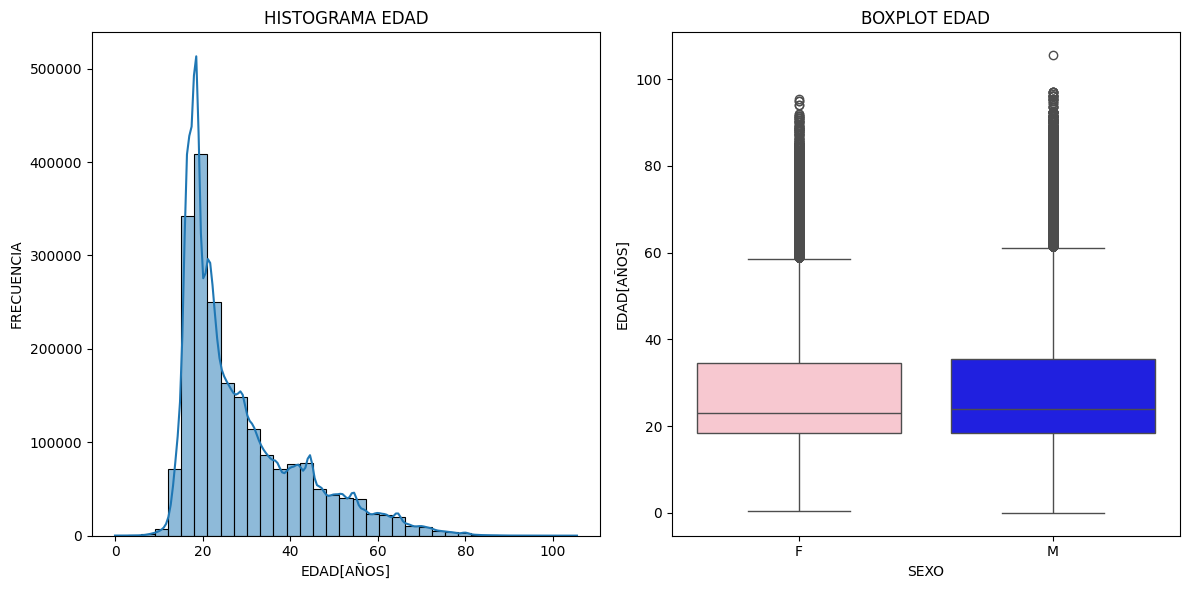

In [71]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 6))

ax[0].set_title("HISTOGRAMA EDAD")
ax[0].set_xlabel("EDAD[AÑOS]")
ax[0].set_ylabel("FRECUENCIA")


sns.histplot(
		data = clean_df,
		x = 'Age',
        binwidth = 3,
        kde = True,
        ax = ax[0]
		)

ax[1].set_title("BOXPLOT EDAD")
ax[1].set_xlabel("SEXO")
ax[1].set_ylabel("EDAD[AÑOS]")

sns.boxplot(
		data = clean_df,
		x = 'Sex',
        y = 'Age',
        palette = {
            'F': 'pink',
            'M': 'blue'
            },
        ax = ax[1]
		)

plt.tight_layout()
plt.show()

**PESO**

C:\Users\Lap-user\AppData\Local\Temp\ipykernel_12768\1922989475.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


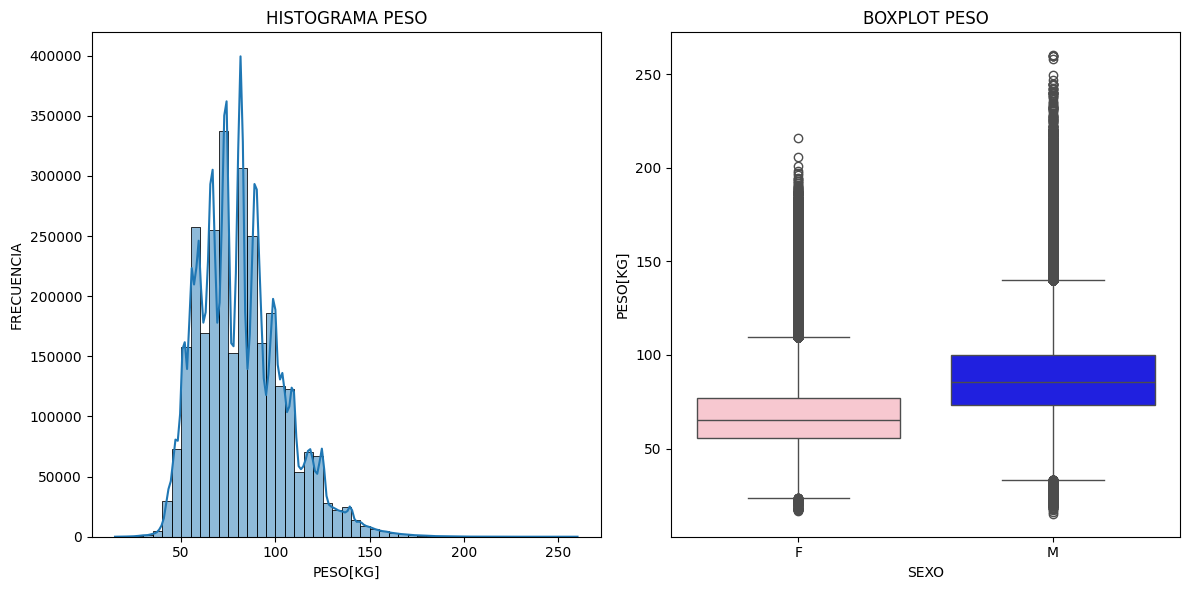

In [73]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 6))

ax[0].set_title("HISTOGRAMA PESO")
ax[0].set_xlabel("PESO[KG]")
ax[0].set_ylabel("FRECUENCIA")


sns.histplot(
		data = clean_df,
		x = 'BodyweightKg',
        binwidth = 5,
        kde = True,
        ax = ax[0]
		)

ax[1].set_title("BOXPLOT PESO")
ax[1].set_xlabel("SEXO")
ax[1].set_ylabel("PESO[KG]")

sns.boxplot(
		data = clean_df,
		x = 'Sex',
        y = 'BodyweightKg',
        palette = {
            'F': 'pink',
            'M': 'blue'
            },
        ax = ax[1]
		)

plt.tight_layout()
plt.show()

## 5.3. Visualización de correlaciones

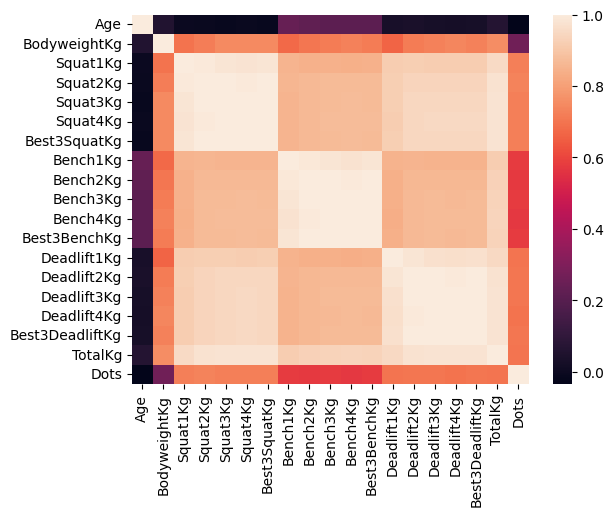

In [78]:
corr = clean_df[[
    'Age',
    'BodyweightKg',
    'Squat1Kg',
    'Squat2Kg',
    'Squat3Kg',
    'Squat4Kg',
    'Best3SquatKg',
    'Bench1Kg',
    'Bench2Kg',
    'Bench3Kg',
    'Bench4Kg',
    'Best3BenchKg',
    'Deadlift1Kg',
    'Deadlift2Kg',
    'Deadlift3Kg',
    'Deadlift4Kg',
    'Best3DeadliftKg',
    'TotalKg',
    'Dots'
    ]].dropna().corr()
sns.heatmap(corr, annot = False)
plt.show()

# Análisis ~ Respuesta a las preguntas

## Pregunta 1

### ¿A qué edad alcanzan el pico de rendimiento los atletas? ¿Difiere entre hombres y mujeres?
Para contestar esta pregunta voy a utilizar la métrica `Dots`. Esta métrica se calcula mediante una fórmula polinómica, que entre otras cosas, estandariza el peso levantado por el peso del atleta, de manera que es la mejor forma de medir el rendimento. Incluso es perfecta para comparar hombres con mujeres, ya que normalmente, estas tienden a pesar menos y a tener menos fuerza comparativamente, lo que ya se incluye en el cálculo de `Dots`.

Por un lado, voy a calcular el edad exacta y después voy a plotearlo.

El punto álgido de rendimiento en hombres se alcanza a los 22.0 años.
El punto álgido de rendimiento en mujeres se alcanza a los 22.0 años.


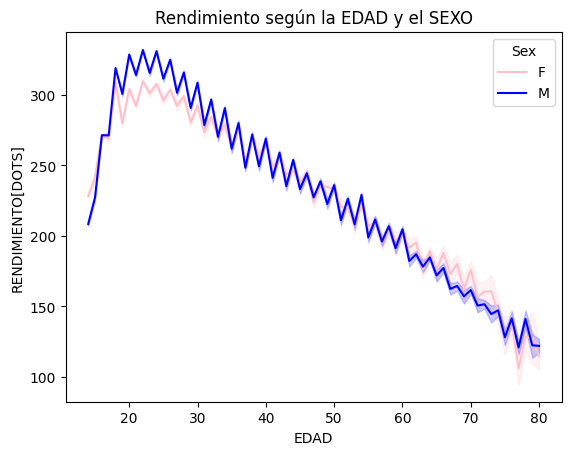

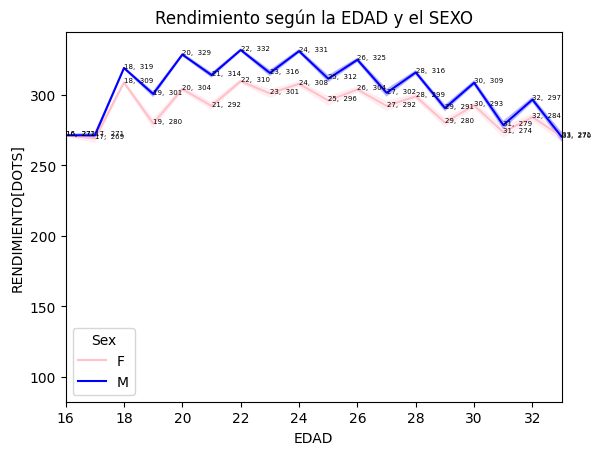

In [19]:
# Terminamos de limpiar para la pregunta concreta:
q1_df = clean_df.dropna(subset = ['Age', 'Dots'])

# Filtramos por edades lógicas [el dataset tiene edades como 0.5 o 115 que carecen de lógica]
q1_df = q1_df[(q1_df['Age'] >= 14) & (q1_df['Age'] <= 80)]

# Plot
fig, ax = plt.subplots()
ax.set_title("Rendimiento según la EDAD y el SEXO")
ax.set_xlabel("EDAD")
ax.set_ylabel("RENDIMIENTO[DOTS]")

sns.lineplot(
		data = q1_df,
		x = q1_df['Age'].round(),
		y = 'Dots',
        hue = 'Sex',
        palette = {
            'F': 'pink',
            'M': 'blue'
            },
        ax = ax
		)

# Output numérico exacto en gráfico
fig, ax = plt.subplots()
ax.set_title("Rendimiento según la EDAD y el SEXO")
ax.set_xlabel("EDAD")
ax.set_ylabel("RENDIMIENTO[DOTS]")
ax.set_xlim(16, 33)

sns.lineplot(
		data = q1_df,
		x = q1_df['Age'].round(),
		y = 'Dots',
        hue = 'Sex',
        palette = {
            'F': 'pink',
            'M': 'blue'
            },
        ax = ax
		)

# Tags en el zoom para ver edad exacta
for line in ax.lines:
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        ax.annotate(f'{x:.0f}, {y: .0f}', (x, y), fontsize = 5)

# Output numérico exacto
q1_df_sol = q1_df.groupby([q1_df['Age'].round(), 'Sex'])['Dots'].mean().reset_index()

max_m = q1_df_sol[q1_df_sol['Sex'] == 'M']['Dots'].idxmax()
max_f = q1_df_sol[q1_df_sol['Sex'] == 'F']['Dots'].idxmax()

# Uso LOC en vez de ILOC porque IDXMAX devuelve LABELS no IDX
print(f"El punto álgido de rendimiento en hombres se alcanza a los {q1_df_sol['Age'].loc[max_m]} años.")
print(f"El punto álgido de rendimiento en mujeres se alcanza a los {q1_df_sol['Age'].loc[max_f]} años.")

### Respuesta
Tanto a nivel visual como en el gráfico podemos ver que el punto álgido se alcanza a los 22 años. Desde los 14 hasta los 18 hay progresión acelerada, que se ralentiza hasta los 22. Tras estos, hay una decaída progresiva cada vez más acelerada. 

**Recomendación**: Es conveniente planificar la carrera deportiva del atleta para hacer coincidir el cúlmen de la preparación física a los 22 años, de manera que solape con el mejor momento biológico, maximizando así las posibilidades de ganar una competición.

**Aclaración**: El zig-zag se produce a que algunas edades no tienen tantos valores, por lo que los valores extremos se notan más. Tras el primer plot, he decidido hacer un zoom sobre la zona crítica para poder ver con claridad cuál es el punto álgido.

## Pregunta 2

### ¿Cómo progresan los atletas dentro de una competición? ¿Suben de peso entre intentos 1 → 2 → 3 o tienden a repetir/bajar?
Para responder a esta pregunta voy a utilizar un ANOVA + PostHoc + Effect Size, ya que con un tamaño muestral tan grande, el p_value sera ~ 0, y lo importante aquí no es tanto si hay diferencias, sino de cuánto es la diferencia. Después graficaré un BOX-PLOT para ver dichas diferencias visualmente.

Elimino todos los registros donde no estén completos los 3 levantamientos, porque para el ANOVA, necesito mantener la correlación entre el L1, L2 y L3 de cada atleta.

**LIMPIEZA**

In [20]:
# Terminamos de limpiar para la pregunta concreta:
bench_df = clean_df.dropna(subset = ['Bench1Kg', 'Bench2Kg', 'Bench3Kg'])
squat_df = clean_df.dropna(subset = ['Squat1Kg', 'Squat2Kg', 'Squat3Kg'])
deadlift_df = clean_df.dropna(subset = ['Deadlift1Kg', 'Deadlift2Kg', 'Deadlift3Kg'])

# Pasamos el df a formato LONG para poder hacer el ANOVA y el BOXPLOT
bench_df = bench_df.melt(
    id_vars = ['Name', 'Sex'],
    value_vars = ['Bench1Kg', 'Bench2Kg', 'Bench3Kg'],
    var_name = 'Intento',
    value_name = 'Peso'
    )

squat_df = squat_df.melt(
    id_vars = ['Name', 'Sex'],
    value_vars = ['Squat1Kg', 'Squat2Kg', 'Squat3Kg'],
    var_name = 'Intento',
    value_name = 'Peso'
    )

deadlift_df = deadlift_df.melt(
    id_vars = ['Name', 'Sex'],
    value_vars = ['Deadlift1Kg', 'Deadlift2Kg', 'Deadlift3Kg'],
    var_name = 'Intento',
    value_name = 'Peso'
    )

**ANOVA**

In [21]:
bench_AN = pg.rm_anova(
    data = bench_df,
    dv = 'Peso',
    within = 'Intento',
    subject = 'Name',
    effsize = 'n2'
    )

squat_AN = pg.rm_anova(
    data = squat_df,
    dv = 'Peso',
    within = 'Intento',
    subject = 'Name',
    effsize = 'n2'
    )

deadlift_AN = pg.rm_anova(
    data = deadlift_df,
    dv = 'Peso',
    within = 'Intento',
    subject = 'Name',
    effsize = 'n2'
    )

display(bench_AN, squat_AN, deadlift_AN)

,Source,ddof1,ddof2,F,p_unc,p_GG_corr,n2,eps,sphericity,W_spher,p_spher
0,Intento,2,422688,1036007.41,0.00,0.00,0.01,0.60,False,0.33,0.00


,Source,ddof1,ddof2,F,p_unc,p_GG_corr,n2,eps,sphericity,W_spher,p_spher
0,Intento,2,425130,1255386.52,0.00,0.00,0.02,0.61,False,0.35,0.00


,Source,ddof1,ddof2,F,p_unc,p_GG_corr,n2,eps,sphericity,W_spher,p_spher
0,Intento,2,495212,1458522.34,0.00,0.00,0.02,0.61,False,0.35,0.00


**POST-HOC: BONFERRONI**

In [22]:
bench_PH = pg.pairwise_tests(
    data = bench_df,
    dv = 'Peso',
    within = 'Intento',
    subject = 'Name',
    alpha = 0.05,
    alternative = 'two-sided',
    padjust = 'bonf',
    effsize = 'cohen',
    return_desc = True,
    )

squat_PH = pg.pairwise_tests(
    data = squat_df,
    dv = 'Peso',
    within = 'Intento',
    subject = 'Name',
    alpha = 0.05,
    alternative = 'two-sided',
    padjust = 'bonf',
    effsize = 'cohen',
    return_desc = True,
    )

deadlift_PH = pg.pairwise_tests(
    data = deadlift_df,
    dv = 'Peso',
    within = 'Intento',
    subject = 'Name',
    alpha = 0.05,
    alternative = 'two-sided',
    padjust = 'bonf',
    effsize = 'cohen',
    return_desc = True,
    )

display(bench_PH, squat_PH, deadlift_PH)

,Contrast,A,B,mean_A,std_A,mean_B,std_B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,cohen
0,Intento,Bench1Kg,Bench2Kg,100.82,41.74,107.52,43.25,True,True,-926.44,211344.00,two-sided,0.00,0.00,bonf,inf,-0.16
1,Intento,Bench1Kg,Bench3Kg,100.82,41.74,112.46,44.26,True,True,-1072.76,211344.00,two-sided,0.00,0.00,bonf,inf,-0.27
2,Intento,Bench2Kg,Bench3Kg,107.52,43.25,112.46,44.26,True,True,-939.69,211344.00,two-sided,0.00,0.00,bonf,inf,-0.11


,Contrast,A,B,mean_A,std_A,mean_B,std_B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,cohen
0,Intento,Squat1Kg,Squat2Kg,149.83,53.68,159.96,55.82,True,True,-1020.55,212565.00,two-sided,0.00,0.00,bonf,inf,-0.18
1,Intento,Squat1Kg,Squat3Kg,149.83,53.68,167.96,57.16,True,True,-1181.70,212565.00,two-sided,0.00,0.00,bonf,inf,-0.33
2,Intento,Squat2Kg,Squat3Kg,159.96,55.82,167.96,57.16,True,True,-1027.34,212565.00,two-sided,0.00,0.00,bonf,inf,-0.14


,Contrast,A,B,mean_A,std_A,mean_B,std_B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,cohen
0,Intento,Deadlift1Kg,Deadlift2Kg,163.84,52.97,175.66,55.14,True,True,-1103.24,247606.00,two-sided,0.00,0.00,bonf,inf,-0.22
1,Intento,Deadlift1Kg,Deadlift3Kg,163.84,52.97,184.94,56.53,True,True,-1274.54,247606.00,two-sided,0.00,0.00,bonf,inf,-0.39
2,Intento,Deadlift2Kg,Deadlift3Kg,175.66,55.14,184.94,56.53,True,True,-1099.56,247606.00,two-sided,0.00,0.00,bonf,inf,-0.17


**BOXPLOT**

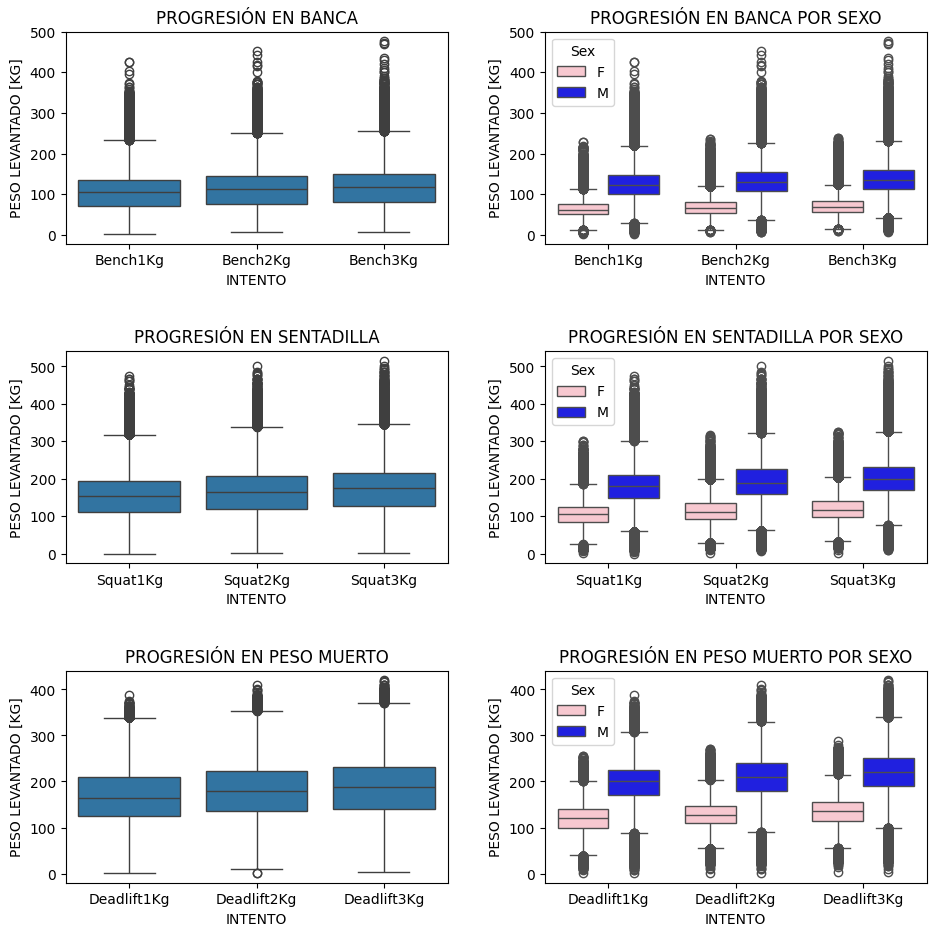

In [23]:
fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize = (10, 10))

# BANCA
ax[0][0].set_title("PROGRESIÓN EN BANCA")
ax[0][0].set_xlabel("INTENTO")
ax[0][0].set_ylabel("PESO LEVANTADO [KG]")

sns.boxplot(
		data = bench_df,
		x = 'Intento',
		y = 'Peso',
        ax = ax[0][0]
		)

# BANCA POR SEXO
ax[0][1].set_title("PROGRESIÓN EN BANCA POR SEXO")
ax[0][1].set_xlabel("INTENTO")
ax[0][1].set_ylabel("PESO LEVANTADO [KG]")

sns.boxplot(
		data = bench_df,
		x = 'Intento',
		y = 'Peso',
        hue = 'Sex',
        palette = {
            'F': 'pink',
            'M': 'blue'
            },
        ax = ax[0][1]
		)

# SQUAT
ax[1][0].set_title("PROGRESIÓN EN SENTADILLA")
ax[1][0].set_xlabel("INTENTO")
ax[1][0].set_ylabel("PESO LEVANTADO [KG]")

sns.boxplot(
		data = squat_df,
		x = 'Intento',
		y = 'Peso',
        ax = ax[1][0]
		)

# SQUAT POR SEXO
ax[1][1].set_title("PROGRESIÓN EN SENTADILLA POR SEXO")
ax[1][1].set_xlabel("INTENTO")
ax[1][1].set_ylabel("PESO LEVANTADO [KG]")

sns.boxplot(
		data = squat_df,
		x = 'Intento',
		y = 'Peso',
        hue = 'Sex',
        palette = {
            'F': 'pink',
            'M': 'blue'
            },
        ax = ax[1][1]
		)

# DEADLIFT
ax[2][0].set_title("PROGRESIÓN EN PESO MUERTO")
ax[2][0].set_xlabel("INTENTO")
ax[2][0].set_ylabel("PESO LEVANTADO [KG]")

sns.boxplot(
		data = deadlift_df,
		x = 'Intento',
		y = 'Peso',
        ax = ax[2][0]
		)

# DEADLIFT POR SEXO
ax[2][1].set_title("PROGRESIÓN EN PESO MUERTO POR SEXO")
ax[2][1].set_xlabel("INTENTO")
ax[2][1].set_ylabel("PESO LEVANTADO [KG]")

sns.boxplot(
		data = deadlift_df,
		x = 'Intento',
		y = 'Peso',
        hue = 'Sex',
        palette = {
            'F': 'pink',
            'M': 'blue'
            },
        ax = ax[2][1]
		)

plt.tight_layout(pad = 3)
plt.show()

### Respuesta
Inicamos con el ANOVA, que cómo se esperaba, ha dado diferencias significativas en todos los grupos dado el número de datos. A continuación, en el post-hoc podemos sacar toda la información junto a los gráficos. Centrándonos primero en el post-hoc (ignorando la fila 1 que es el salto del lift1 al lift3), podemos ver que a pesar de que el tamaño del efecto [cohen] es "pequeño", si lo traducimos a kilos en los levantamientos hay diferencias considerables para los 3 ejercicios y en todos los lanzamientos.

Justamente esto es lo que podemos ver en los gráficos. Si nos centramos primero en los de la izquierda, vemos que todos tienen es forma de escalera, corroborando que de un levantamiento al siguiente suben peso. Si por ejemplo observamos las medias de los grupos en el post-hoc podemos ver que en banca, del primer levantamiento al segundo hay casi 7 kilos de mejora, y de este segundo al tercero otros 5. Cómo decía, puede parecer poco, pero 5 kilos extra en la barra llegados los niveles de exigencia es muchísimo.

Adicionalmente he decidido crear gráficos con la distribución por sexo para, de manera gráfica, apreciar si los hombres y las mujeres mejoran por igual tras cada levantamiento. La respuesta es que sí. A pesar de que los hombres cargan mayores pesos, la progresión entre lanzamientos es prácticamente idéntica.

## Pregunta 3

### ¿En qué levantamiento (squat, bench, deadlift) se producen más fallos en el 3er intento?

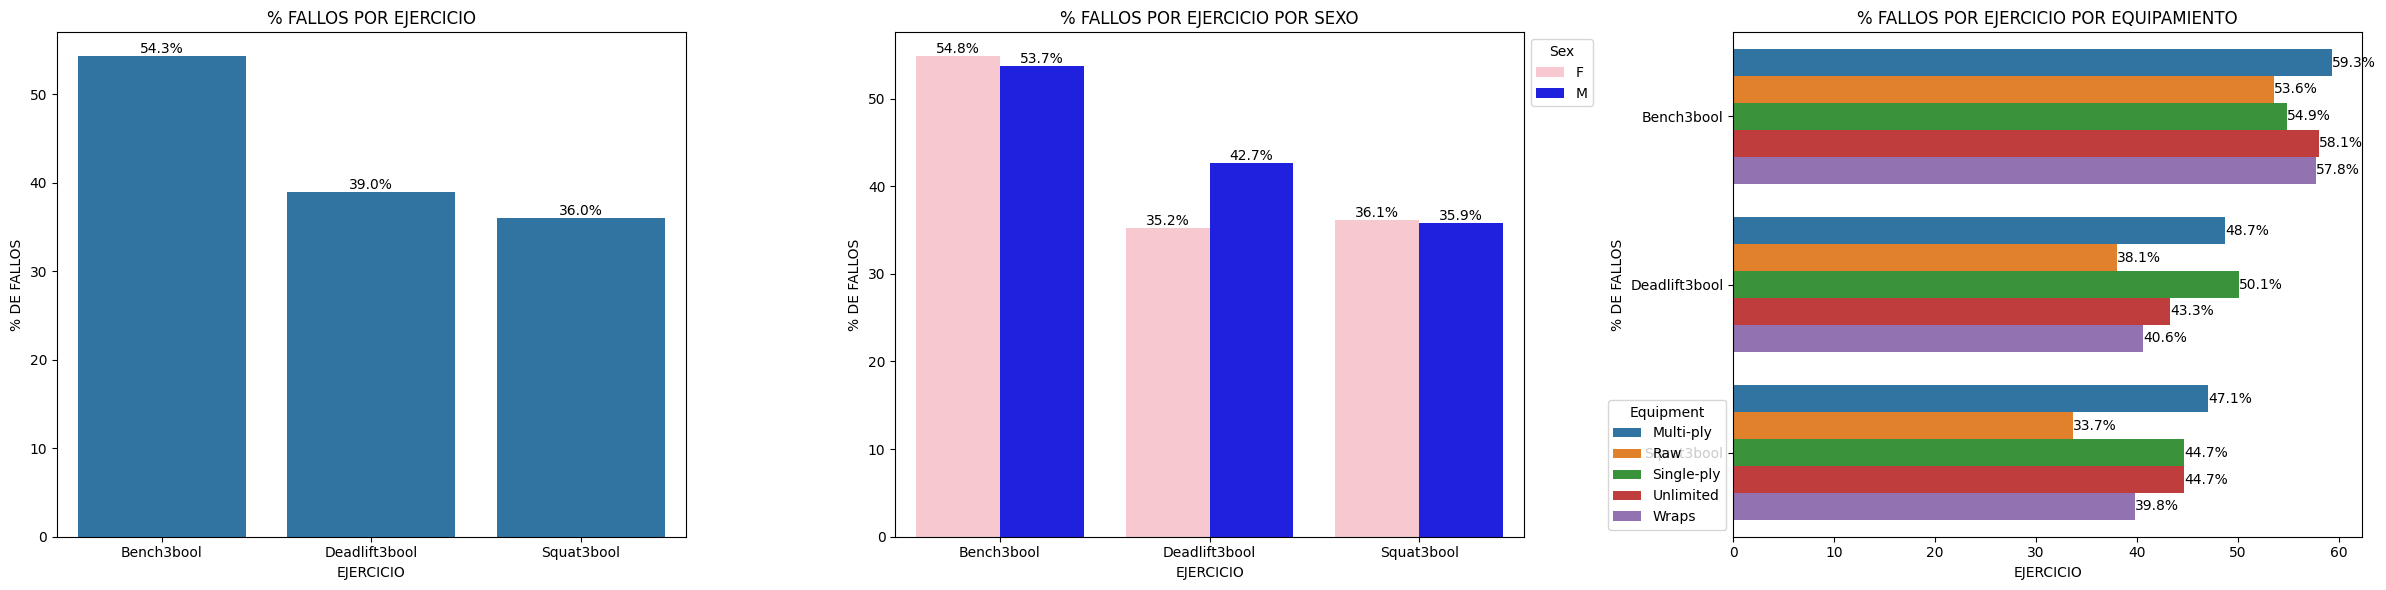

Equipment
Raw           2426347
Single-ply     597363
Wraps          100734
Multi-ply       20074
Unlimited        3115
Name: count, dtype: int64

In [29]:
# Hacemos el melt para poder pintarlo todo en el mismo gráfico.
q3_df = clean_df.melt(
    id_vars = ['Name', 'Sex', 'Equipment'],
    value_vars = ['Bench3bool', 'Squat3bool', 'Deadlift3bool'],
    var_name = 'Levantamiento',
    value_name = 'Éxito'
)

# Limpiamos los LEVANTAMIENTOS (no atletas) vacíos
q3_df = q3_df.dropna(subset = ['Éxito'])

# Ahora normalizamos los fallos por levantamientos totales (%) para sexo y equipamiento
fallo_sexo_df = q3_df.groupby(['Levantamiento', 'Sex'])['Éxito'].apply(lambda x: (x == False).mean() * 100).reset_index(name = 'Fallos(%)')
fallo_equip_df = q3_df.groupby(['Levantamiento', 'Equipment'])['Éxito'].apply(lambda x: (x == False).mean() * 100).reset_index(name = 'Fallos(%)')

# Plot
fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (24, 6))

ax[0].set_title("% FALLOS POR EJERCICIO")
ax[0].set_xlabel("EJERCICIO")
ax[0].set_ylabel("% DE FALLOS")

sns.barplot(
    data = fallo_sexo_df,
    x = 'Levantamiento',
    y = 'Fallos(%)',
    orient = 'v',
    errorbar = None,
    ax = ax[0]    
)

ax[0].bar_label(ax[0].containers[0], fmt = '%.1f%%')

# Plot por sexo
ax[1].set_title("% FALLOS POR EJERCICIO POR SEXO")
ax[1].set_xlabel("EJERCICIO")
ax[1].set_ylabel("% DE FALLOS")

sns.barplot(
    data = fallo_sexo_df,
    x = 'Levantamiento',
    y = 'Fallos(%)',
    hue = 'Sex',
    orient = 'v',
    palette = {
            'F': 'pink',
            'M': 'blue'
            },
    errorbar = None,
    ax = ax[1]
)

for container in ax[1].containers:
    ax[1].bar_label(container, fmt='%.1f%%')

sns.move_legend(ax[1], "upper left", bbox_to_anchor=(1, 1))

# Plot por equipamiento
ax[2].set_title("% FALLOS POR EJERCICIO POR EQUIPAMIENTO")
ax[2].set_xlabel("EJERCICIO")
ax[2].set_ylabel("% DE FALLOS")

sns.barplot(
    data = fallo_equip_df,
    x = 'Fallos(%)',
    y = 'Levantamiento',
    hue = 'Equipment',
    orient = 'h',
    errorbar = None,
    ax = ax[2]
)

for container in ax[2].containers:
    ax[2].bar_label(container, fmt='%.1f%%')

sns.move_legend(ax[2], "lower right", bbox_to_anchor=(0, 0))

plt.tight_layout()
plt.show()

display(q3_df['Equipment'].value_counts())

### Respuesta
Claramente, el ejercicio en el que más se falla a la tercera es el press de banca, donde se falla más de la mitad de los intentos sin importar el sexo. Luego, depende del sexo. En el caso de los hombres, fallan bastante más en peso muerto que en sentadilla, mientras que las mujeres fallan prácticamente por igual en ambos ejercicios. El punto clave es que, para los 3 ejercicios, y especialmente para el press de banca, el tercer levantamiento tiene unas probabilidaes relativamente altas de fallarse. 

Curiosamente, si nos ponemos a mirar el porcentaje de fallos por equipamiento podemos ver que `RAW` es siempre el 'equipamiento' con menor % de fallos. Sin embargo, dado que `RAW` tiene ~ 2.5M de levantamientos y el siguiente con más levantamientos es `SINGLE-PLY`, que tiene ~ 60K y `UNLIMITED` que es el que menos tiene con ~ 3K, podemos decir que los resultados de todas las categorías menos `RAW` no son del todo fiables ya que la pequeña muestra (en comparación) disminuye la robustez del análisis.

**Recomendación**: Esta pregunta cambia por completo la narrativa de la segunda pregunta. Sabiendo que la mayoría de atletas hace levantamientos ascendentes siendo su último intento el más fuerte, el que más probabilidades tiene de fallar y el que decide quién gana, quizá la estrategia ganadora es hacer un segundo levantamiento muy fuerte. Pongamos que siguiendo esta estrategia tu segundo levantamiento te pone a la cabeza. Ahora el resto de atletas tiene que arriesgar para superarte, lo que aumentará aún más las posibilidades de fallar debido a la presión. Además, siendo consciente de esto, igual es mejor idea hacer un tercer levantamiento sin arriesgar tanto para asegurarte levantarlo, especialmente en banca.

## Pregunta 4

### ¿Los atletas que compiten en más eventos full lifting rinden más o menos que los que se especializan en un sólo tipo de levantamiento?
Hay un concepto importante a tener en cuenta. No podemos utilizar `Dots` para comparar los rendimientos en función de los levantamientos realizados porque Dots se calcula en base al `TotalKg` levantado, consecuentemente, alguien que participe en más de una competición siempre tendrá mayor `Dots` que alguien que sólo participe en una. Para ello, voy a crear un nuevo pseudo_Dots por cada ejercicio donde dividiré el el mejor de los 3 levantamientos entre el peso. También tendré en cuenta el % de fallos para comparar el rendimiento.

**PSEUDO_DOTS**

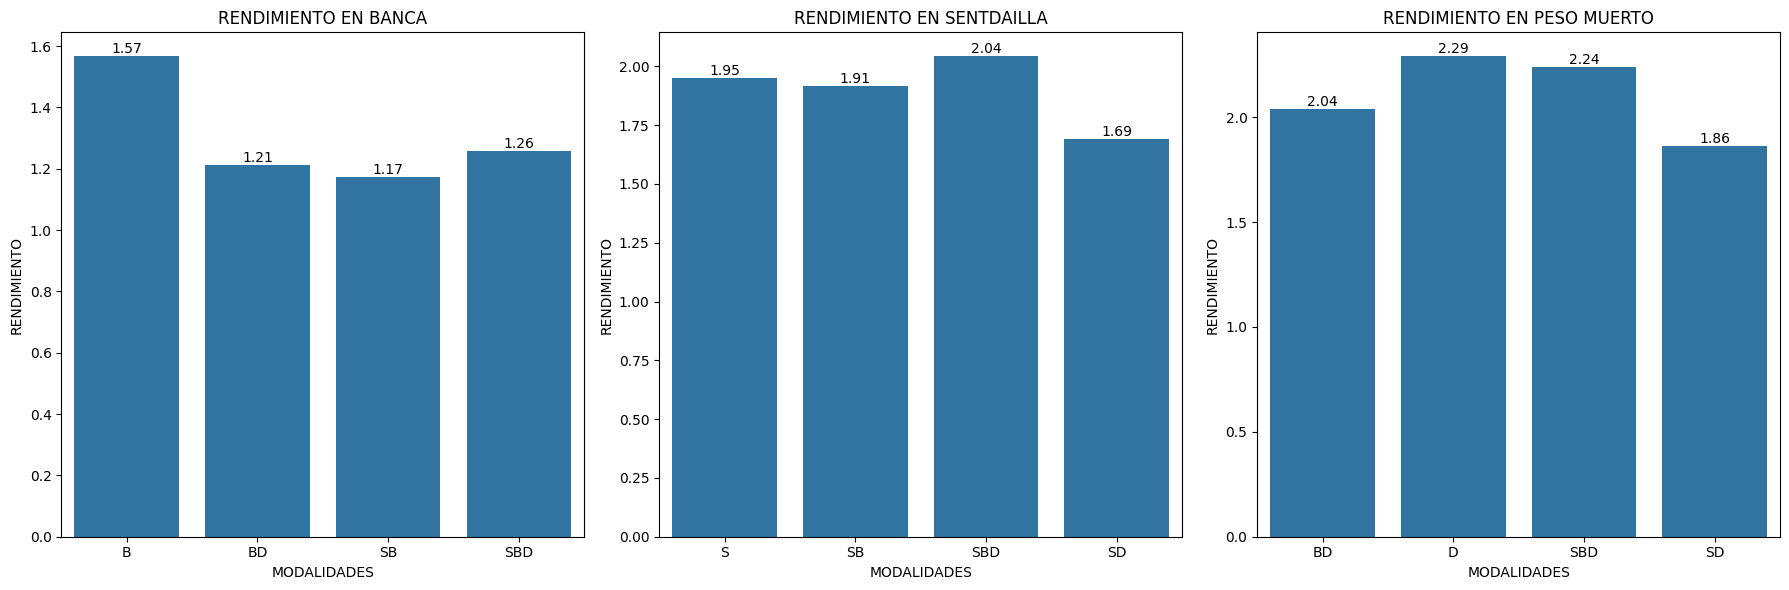

In [41]:
# Terminamos de limpiar el DF para la pregunta
q4a_df = clean_df.dropna(subset = ['Event'])
q4a_df['Dot_Bench'] = q4a_df['Best3BenchKg']/q4a_df['BodyweightKg']
q4a_df['Dot_Squat'] = q4a_df['Best3SquatKg']/q4a_df['BodyweightKg']
q4a_df['Dot_Deadlift'] = q4a_df['Best3DeadliftKg']/q4a_df['BodyweightKg']

# Creamos los DF para cada ejercicio (y eliminamos columnas estúpidas)
dot_bench_df = q4a_df[~q4a_df['Event'].isin(['D', 'S', 'SD'])].dropna(subset = ['Best3BenchKg'])
dot_bench_df['Event'] = dot_bench_df['Event'].cat.remove_unused_categories()

dot_squat_df = q4a_df[~q4a_df['Event'].isin(['D', 'B', 'BD'])].dropna(subset = ['Best3SquatKg'])
dot_squat_df['Event'] = dot_squat_df['Event'].cat.remove_unused_categories()

dot_deadlift_df = q4a_df[~q4a_df['Event'].isin(['B', 'S', 'SB'])].dropna(subset = ['Best3DeadliftKg'])
dot_deadlift_df['Event'] = dot_deadlift_df['Event'].cat.remove_unused_categories()

# PLOT BANCA
fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (18, 6))

ax[0].set_title("RENDIMIENTO EN BANCA")
ax[0].set_xlabel("MODALIDADES")
ax[0].set_ylabel("RENDIMIENTO")

sns.barplot(
    data = dot_bench_df,
    x = 'Event',
    y = 'Dot_Bench',
    orient = 'v',
    errorbar = None,
    ax = ax[0]    
)

ax[0].bar_label(ax[0].containers[0], fmt = '%.2f')

# PLOT SENTADILLA
ax[1].set_title("RENDIMIENTO EN SENTDAILLA")
ax[1].set_xlabel("MODALIDADES")
ax[1].set_ylabel("RENDIMIENTO")

sns.barplot(
    data = dot_squat_df,
    x = 'Event',
    y = 'Dot_Squat',
    orient = 'v',
    errorbar = None,
    ax = ax[1]
)

ax[1].bar_label(ax[1].containers[0], fmt = '%.2f')

# PLOT PESO MUERTO
ax[2].set_title("RENDIMIENTO EN PESO MUERTO")
ax[2].set_xlabel("MODALIDADES")
ax[2].set_ylabel("RENDIMIENTO")

sns.barplot(
    data = dot_deadlift_df,
    x = 'Event',
    y = 'Dot_Deadlift',
    orient = 'v',
    errorbar = None,
    ax = ax[2]
)

ax[2].bar_label(ax[2].containers[0], fmt = '%.2f')

plt.tight_layout()
plt.show()

**FAIL_RATE**

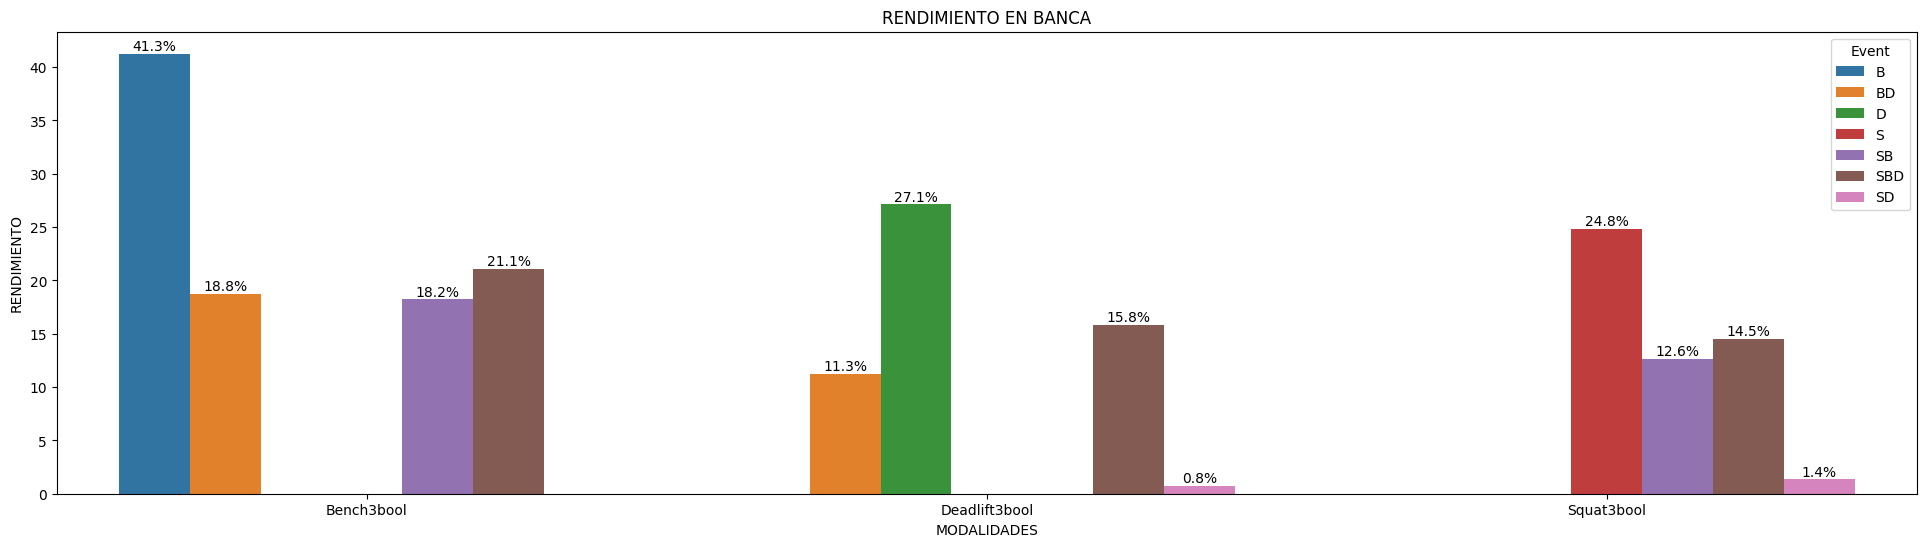

In [ ]:
q4b_df = q4a_df.melt(
    id_vars = ['Name', 'Event'],
    value_vars = ['Bench3bool', 'Squat3bool', 'Deadlift3bool'],
    var_name = 'Levantamiento',
    value_name = 'Éxito'
)

q4b_df = q4b_df.groupby(['Levantamiento', 'Event'])['Éxito'].apply(lambda x: (x == False).mean() * 100).reset_index(name = 'Fallos(%)')
q4b_df = q4b_df[q4b_df['Fallos(%)'] > 0]   # Para quitar las etiquetas que saldrían con 0.0

# PLOT BANCA
fig, ax = plt.subplots(figsize = (24, 6))

ax.set_title("RENDIMIENTO EN BANCA")
ax.set_xlabel("MODALIDADES")
ax.set_ylabel("RENDIMIENTO")

sns.barplot(
    data = q4b_df,
    x = 'Levantamiento',
    y = 'Fallos(%)',
    orient = 'v',
    hue = 'Event',
    errorbar = None,
    ax = ax
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.show()

### Respuesta
El único ejercicio donde parece haber una clara ventaja para especializarse en comparación con combinarlo con otros es el press de banca. Para sentadilla y peso muerto parece que la fuerza general desarrollada en los otros ejercicios es transferible. En cuánto al fallo en el 3 intento [donde normalmente se juegan todo], parece que los especialistas fallan mucho más que el resto. Esto quizá se deba a que al sólo enfocarse en un ejercicio, tratan de llegar mucho más al límite en dicho levantamiento.

**Recomendación**: Si quieres progresar y destacar en banca, deberías trabajar banca de manera exclusiva. Para los otros 2 ejercicios, puedes competir en la 3 modalidad, siempre poniendo tu foco y energía en el ejercicio donde quieras destacar. A la hora de planificar tu tercer intento, igual que recomendaba anteriormente, arriesgar demasiado al 3 intento puede ser perjudicial, especialmente en banca.

## Pregunta 5

### ¿Qué exito tiene el 4º intento?
El 4º levantamiento en powerlifting no cuenta, pero permite a los atletas arriesgar sin miedo para medir su fuerza real. Vamos a evaluar cuántas veces consiguen los atletas superarse en este 4 intento.

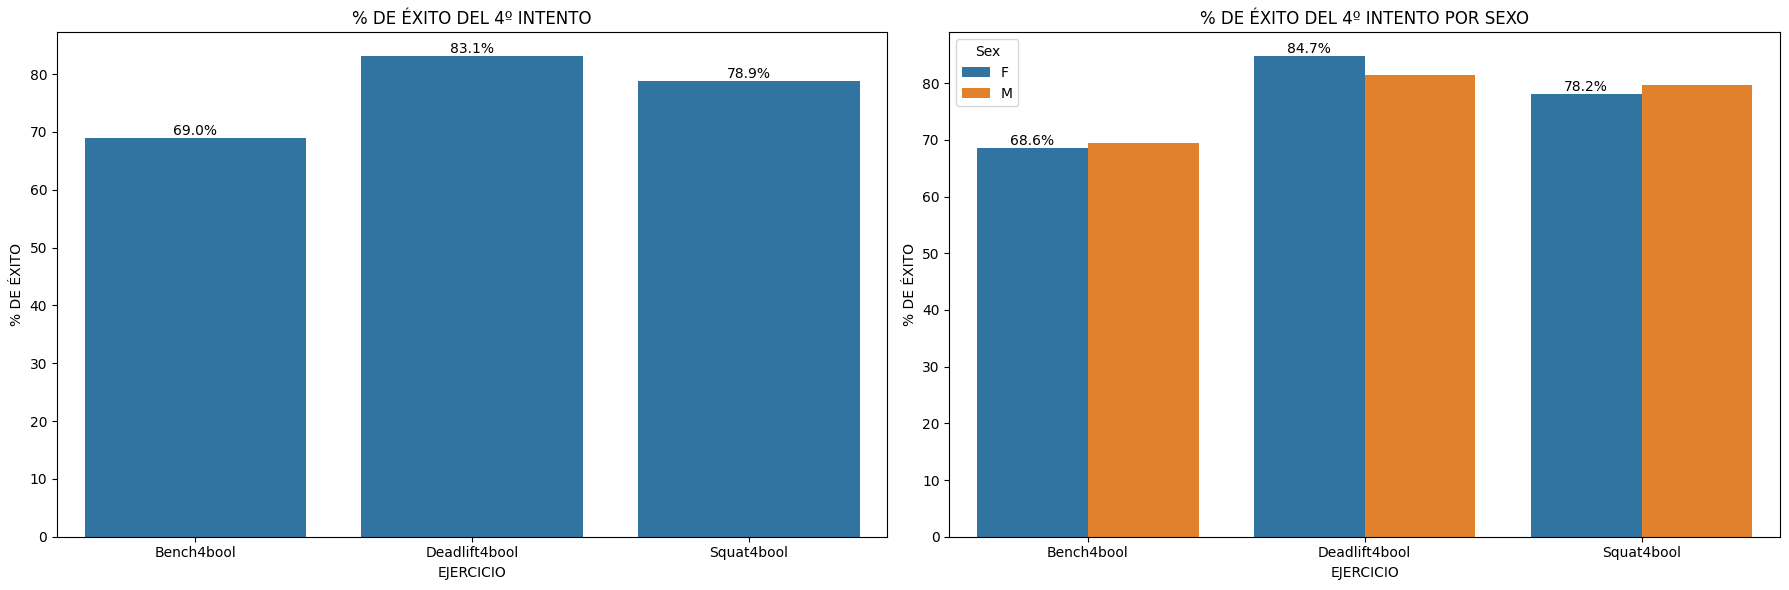

In [56]:
# Hacemos el melt para poder pintarlo todo en el mismo gráfico
q5_df = clean_df.melt(
    id_vars = ['Sex',],
    value_vars = ['Bench4bool', 'Squat4bool', 'Deadlift4bool'],
    var_name = 'Levantamiento',
    value_name = 'Éxito'
)

# Limpiamos los LEVANTAMIENTOS (no atletas) vacíos
q5_df = q5_df.dropna(subset = ['Éxito'])

conteo = q5_df['Sex'].value_counts()

# Ahora normalizamos los fallos por levantamientos totales (%) para sexo y equipamiento
q5_df = q5_df.groupby(['Levantamiento', 'Sex'])['Éxito'].apply(lambda x: (x == True).mean() * 100).reset_index(name = 'Éxitos(%)')

# Plot
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (18, 6))

ax[0].set_title("% DE ÉXITO DEL 4º INTENTO")
ax[0].set_xlabel("EJERCICIO")
ax[0].set_ylabel("% DE ÉXITO")

sns.barplot(
    data = q5_df,
    x = 'Levantamiento',
    y = 'Éxitos(%)',
    orient = 'v',
    errorbar = None,
    ax = ax[0]    
)

ax[0].bar_label(ax[0].containers[0], fmt = '%.1f%%')

# Plot por sexo
ax[1].set_title("% DE ÉXITO DEL 4º INTENTO POR SEXO")
ax[1].set_xlabel("EJERCICIO")
ax[1].set_ylabel("% DE ÉXITO")

sns.barplot(
    data = q5_df,
    x = 'Levantamiento',
    y = 'Éxitos(%)',
    orient = 'v',
    hue = 'Sex',
    errorbar = None,
    ax = ax[1]    
)

ax[1].bar_label(ax[1].containers[0], fmt = '%.1f%%')

plt.tight_layout()
plt.show()

### Respuesta
En corcondancia con lo anterior, el press de banca sigue siendo el ejercicio donde más se fala. Aún así, el 4 intento es muy fructífero para los 3 ejercicios sin importar el sexo, ya que la mayoría de la gente que lo tira, suele conseguirlo. Quizá convendría evaluar un sesgo en los datos, dado que es posible que gente que tira el 4 intento y lo falle no lo apunte, pero esto no es tan probable para los que lo consiguen.

**Recomendación**: Deberías siempre tirar un 4º intento para testearte a tí mismo y conocer nuevos límites de cara a próximas competiciones.

### Análisis univariado de variables categóricas
Realizar gráficos de barras para analizar la frecuencia de las variables categóricas.

In [26]:
# Bar plot for a categorical variable
# df['categorical_column'].value_counts().plot(kind='bar')
# plt.show()

### Análisis bivariado entre variables
Explorar relaciones entre variables numéricas y categóricas mediante scatterplots y tablas cruzadas.

In [27]:
# Scatterplot
# plt.scatter(df['numeric_column_x'], df['numeric_column_y'])
# plt.show()

# Crosstab for two categorical variables   
# pd.crosstab(df['categorical_column1'], df['categorical_column2'])